Plotting Time-Series grid for all files...


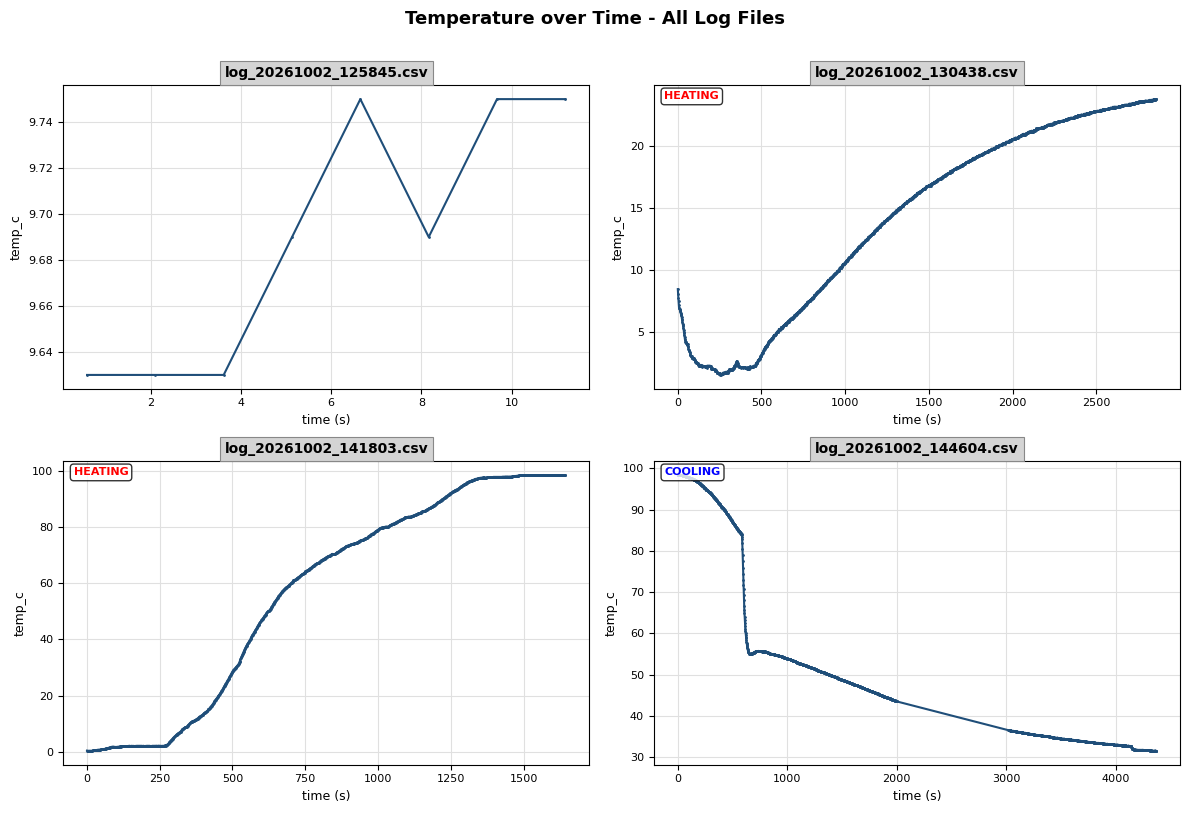


Plot saved as 'temp_vs_time_all_files.png'
Total files plotted: 4


In [17]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of CSV files from your git repository
csv_files = [
    "log_20261002_125845.csv",
    "log_20261002_130438.csv",
    "log_20261002_141803.csv",
    "log_20261002_144604.csv"
]

# If files are in a data folder, uncomment this:
folder_path = "../../data"
csv_files = [os.path.join(folder_path, f) for f in csv_files]

def plot_time_series_grid(file_list, n_cols=2):
    """
    Plot temp_c vs time for each file in a grid layout
    """
    n_files = len(file_list)
    if n_files == 0:
        print("No files to plot")
        return
    
    n_rows = math.ceil(n_files / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, file_path in enumerate(file_list):
        ax = axes_flat[idx]
        file_name = os.path.basename(file_path)
        
        # Read CSV file
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        # Check if required columns exist
        if 'temp_c' not in df.columns:
            print(f"Warning: 'temp_c' column not found in {file_name}")
            ax.set_title(file_name, fontsize=10, fontweight='bold',
                        pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                        facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
            ax.text(0.5, 0.5, 'No temp_c column', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Plot temp_c vs time
        if 'time_ms' in df.columns:
            # Convert milliseconds to seconds
            t_sec = df['time_ms'] / 1000.0
            ax.plot(t_sec, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time (s)", fontsize=9)
        elif 'time' in df.columns:
            ax.plot(df['time'], df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time", fontsize=9)
        else:
            # Use index as time
            ax.plot(df.index, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("sample", fontsize=9)
        
        ax.set_ylabel("temp_c", fontsize=9)
        ax.set_title(file_name, fontsize=10, fontweight='bold',
                    pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                    facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
        
        # Add grid
        ax.grid(True, color="#e0e0e0", linestyle="-", linewidth=0.8)
        ax.tick_params(labelsize=8)
        
        # Determine if heating or cooling based on trend
        if len(df) > 10:
            # Compare first 10% and last 10% of data
            n_samples = len(df)
            first_avg = df['temp_c'].iloc[:n_samples//10].mean()
            last_avg = df['temp_c'].iloc[-n_samples//10:].mean()
            
            if last_avg > first_avg + 1:
                trend = "HEATING"
                color = "red"
            elif last_avg < first_avg - 1:
                trend = "COOLING"
                color = "blue"
            else:
                trend = "STABLE"
                color = "green"
            
            ax.text(0.02, 0.98, trend, transform=ax.transAxes, fontsize=8, 
                   fontweight='bold', color=color, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Hide unused subplots
    for j in range(n_files, len(axes_flat)):
        fig.delaxes(axes_flat[j])
    
    fig.suptitle("Temperature over Time - All Log Files", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("temp_vs_time_all_files.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 'temp_vs_time_all_files.png'")
    print(f"Total files plotted: {n_files}")

# Run the plot
print("Plotting Time-Series grid for all files...")
plot_time_series_grid(csv_files, n_cols=2)

In [18]:
# ==========================================
# 1. Define the correct file paths
# ==========================================
heating_file = "../../data/log_20261002_141803.csv"
cooling_file = "../../data/log_20261002_144604.csv"

# ==========================================
# 2. Load RAW Data
# ==========================================
# Heating
raw_heating_df = pd.read_csv(heating_file)
raw_heating_df.columns = raw_heating_df.columns.str.strip()
raw_heating_df['source'] = os.path.basename(heating_file)

# Cooling
raw_cooling_df = pd.read_csv(cooling_file)
raw_cooling_df.columns = raw_cooling_df.columns.str.strip()
raw_cooling_df['source'] = os.path.basename(cooling_file)

print(f"Raw Heating Data loaded: {len(raw_heating_df)} rows")

print(f"Raw Cooling Data loaded: {len(raw_cooling_df)} rows")

Raw Heating Data loaded: 1079 rows
Raw Cooling Data loaded: 2207 rows


In [19]:
raw_heating_df.head(3)  # Display first 3 rows of heating data


,time_ms,temp_c,temp_k,adc,source
0,596,0.44,273.59,97,log_20261002_141803.csv
1,2111,0.37,273.52,97,log_20261002_141803.csv
2,3624,0.37,273.52,96,log_20261002_141803.csv


In [20]:
raw_cooling_df.head(3)  # Display first 3 rows of cooling data


,time_ms,temp_c,temp_k,adc,source
0,619,98.37,371.52,849,log_20261002_144604.csv
1,2156,98.37,371.52,849,log_20261002_144604.csv
2,3694,98.31,371.46,849,log_20261002_144604.csv


In [21]:
import matplotlib.pyplot as plt

def plot_adc_vs_temp(x, y, title="ADC vs Temperature", x_label="ADC Value", y_label="Temperature (°C)", color='blue', alpha=0.5):
    """
    Plots ADC values against Temperature (°C).
    
    Parameters:
    - x: array-like, ADC values (e.g., df['adc'])
    - y: array-like, Temperature values in Celsius (e.g., df['temp_c'])
    - title: str, title of the plot
    - x_label: str, label for the x-axis
    - y_label: str, label for the y-axis
    - color: str, color of the scatter points
    - alpha: float, transparency of the scatter points (0.0 to 1.0)
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color=color, alpha=alpha, s=15, edgecolors='none')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

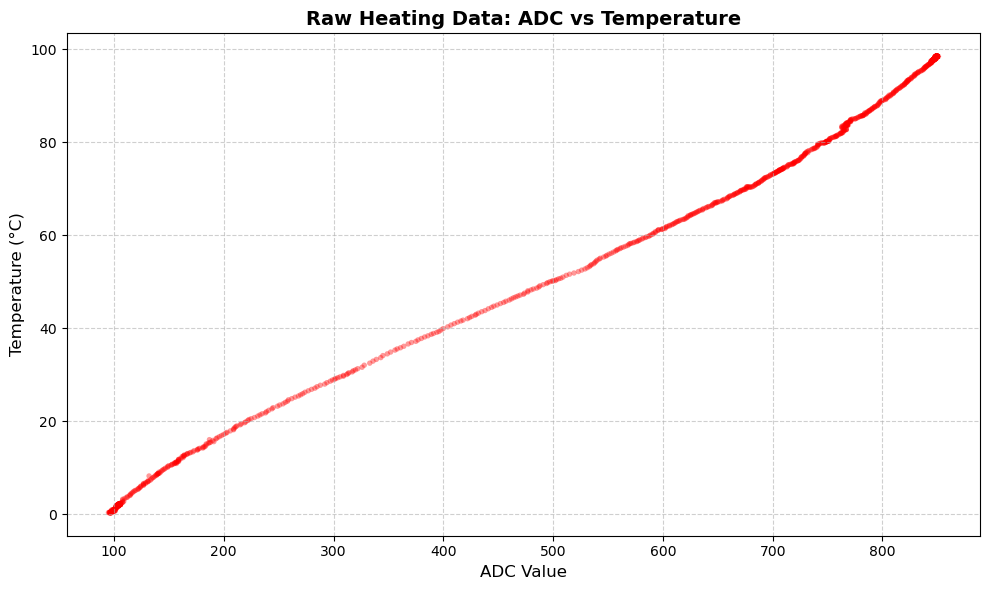

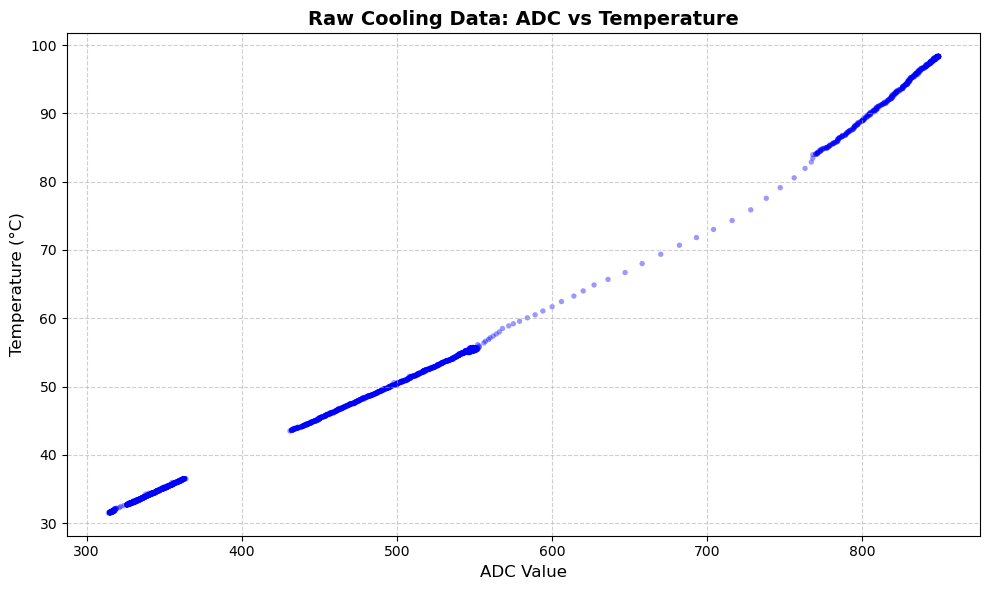

In [22]:
# 1. Plot Raw Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=raw_heating_df['adc'], 
    y=raw_heating_df['temp_c'], 
    title="Raw Heating Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

# 2. Plot Raw Cooling Data
# Replace 'cooling_df' with the actual name of your cooling dataframe variable
plot_adc_vs_temp(
    x=raw_cooling_df['adc'], 
    y=raw_cooling_df['temp_c'], 
    title="Raw Cooling Data: ADC vs Temperature", 
    color='blue', 
    alpha=0.4
)

In [23]:
# ==========================================
# 3. Outlier Removal Function
# ==========================================
def remove_outliers_residual(df, x_col='adc', y_col='temp_c', degree=3, sigma_mult=2.5, max_iter=3):
    """
    Iteratively removes outliers based on residuals from a polynomial fit.
    """
    # Drop any existing NaNs first
    clean_df = df.dropna(subset=[x_col, y_col]).copy()
    outliers_list = []
    
    for i in range(max_iter):
        if len(clean_df) < degree + 1:
            break
            
        x = clean_df[x_col].values
        y = clean_df[y_col].values
        
        # Fit polynomial
        coeffs = np.polyfit(x, y, degree)
        poly = np.poly1d(coeffs)
        
        # Calculate residuals
        y_pred = poly(x)
        residuals = y - y_pred
        
        # Calculate threshold (e.g., 2.5 * standard deviation)
        std_res = np.std(residuals)
        threshold = sigma_mult * std_res
        
        # Identify outliers
        outlier_mask = np.abs(residuals) > threshold
        outliers_list.append(clean_df[outlier_mask])
        
        # Keep only the inliers for the next iteration
        clean_df = clean_df[~outlier_mask]
        
        # Stop if no new outliers were found
        if not outlier_mask.any():
            break
            
    outliers_df = pd.concat(outliers_list, ignore_index=True) if outliers_list else pd.DataFrame()
    return clean_df, outliers_df


# ==========================================
# 4. Clean Data (Remove Outliers)
# ==========================================
# Clean Heating
clean_heating_df, outliers_heating_df = remove_outliers_residual(
    raw_heating_df, 
    x_col='adc', 
    y_col='temp_c', 
    degree=3, 
    sigma_mult=2.5,
    max_iter=3
)

# Clean Cooling
clean_cooling_df, outliers_cooling_df = remove_outliers_residual(
    raw_cooling_df, 
    x_col='adc', 
    y_col='temp_c', 
    degree=3, 
    sigma_mult=2.5,
    max_iter=3
)

# ==========================================
# 5. Print Cleaning Summary
# ==========================================
print("\n--- Heating Cleaning Results ---")
print(f"After cleaning: {len(clean_heating_df)} rows")
print(f"Outliers removed: {len(outliers_heating_df)} rows")

print("\n--- Cooling Cleaning Results ---")
print(f"After cleaning: {len(clean_cooling_df)} rows")
print(f"Outliers removed: {len(outliers_cooling_df)} rows")


--- Heating Cleaning Results ---
After cleaning: 1071 rows
Outliers removed: 7 rows

--- Cooling Cleaning Results ---
After cleaning: 2058 rows
Outliers removed: 147 rows


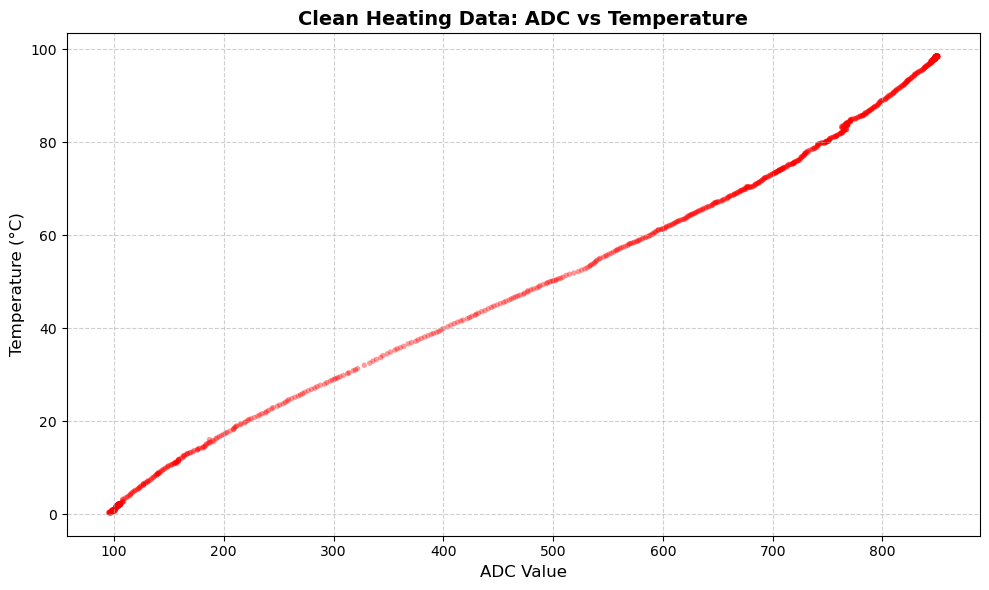

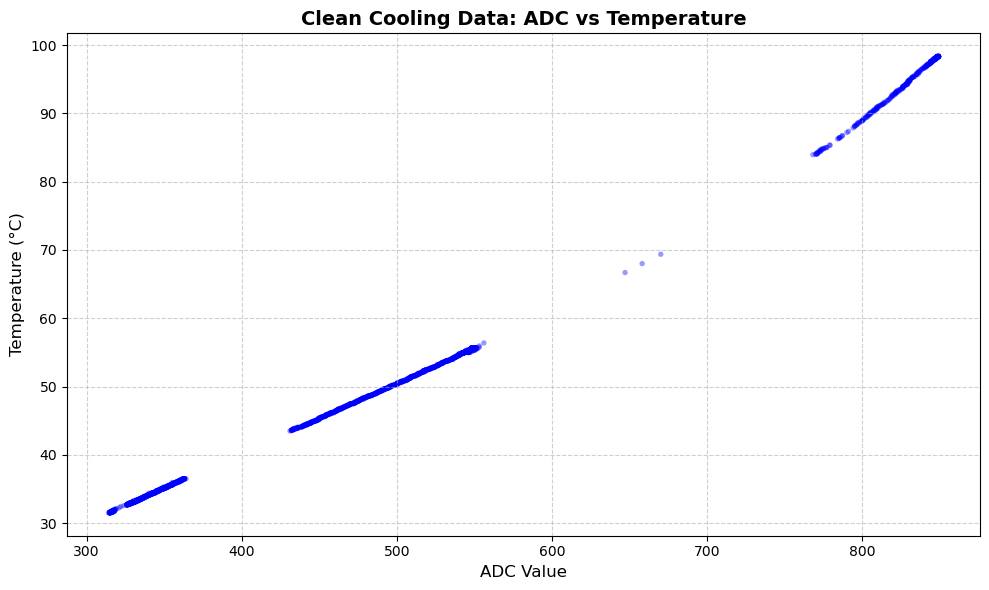

In [24]:
# 1. Plot Clean Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=clean_heating_df['adc'], 
    y=clean_heating_df['temp_c'], 
    title="Clean Heating Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

# 2. Plot Clean Cooling Data
# Replace 'cooling_df' with the actual name of your cooling dataframe variable
plot_adc_vs_temp(
    x=clean_cooling_df['adc'], 
    y=clean_cooling_df['temp_c'], 
    title="Clean Cooling Data: ADC vs Temperature", 
    color='blue', 
    alpha=0.4
)